### Importing libraries

In [79]:
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


### importing raw data and understanding....

In [80]:
df = pd.read_csv(
    "C:\\Users\\sk\\Documents\\backend\\machineai\\Projects\\customer_segmentation_django\\data\\raw\\OnlineRetail.csv",
    encoding="ISO-8859-1"
)

In [81]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [82]:
print(df.shape)

(541909, 8)


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [84]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data Cleaning...

In [85]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [86]:
df.dropna(inplace=True)

In [87]:
print(df.shape)
df.isnull().sum()

(406829, 8)


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [88]:
df.duplicated().sum()

np.int64(5225)

In [89]:
df.drop_duplicates(inplace=True)

In [90]:
df.duplicated().sum()

np.int64(0)

### BUSINESS DATA FILTERING

In [91]:
df = df[
    ~df["InvoiceNo"]
    .astype(str)
    .str.contains("C")
]

In [92]:
print(df.shape)

(392732, 8)


### FEATURE ENGINEERING

In [93]:
df["TotalPrice"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

In [94]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France,14.85


In [95]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [96]:
df.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  str           
 1   StockCode    392732 non-null  str           
 2   Description  392732 non-null  str           
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
 8   TotalPrice   392732 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.0 MB


In [97]:
today = dt.datetime(
    2011,
    12,
    11
)

In [98]:
rfm = df.groupby(
    "CustomerID"
).agg({

    "InvoiceDate": lambda x:
        (today - x.max()).days,

    "InvoiceNo": "nunique",

    "TotalPrice": "sum"

})

In [99]:
print(rfm.shape)
rfm.head()

(4339, 3)


,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


In [100]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,3,7,4310.00
12348.0,76,4,1797.24
12349.0,19,1,1757.55
12350.0,311,1,334.40


plotting datas

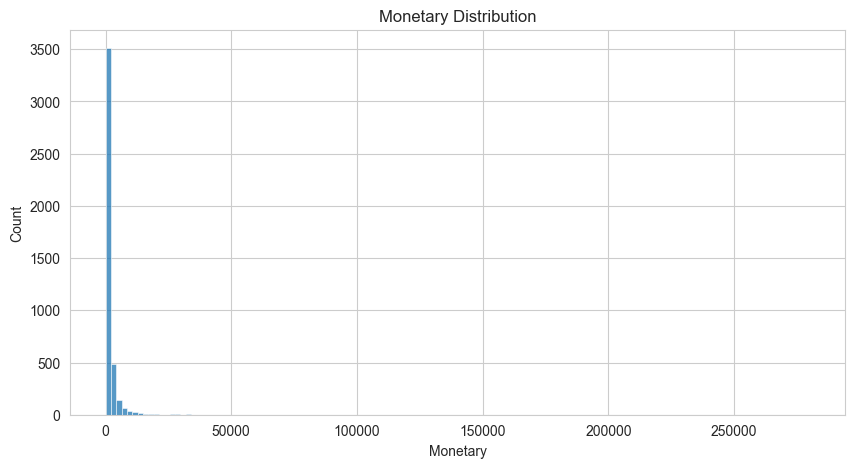

In [101]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Monetary"])

plt.title("Monetary Distribution")
plt.show()

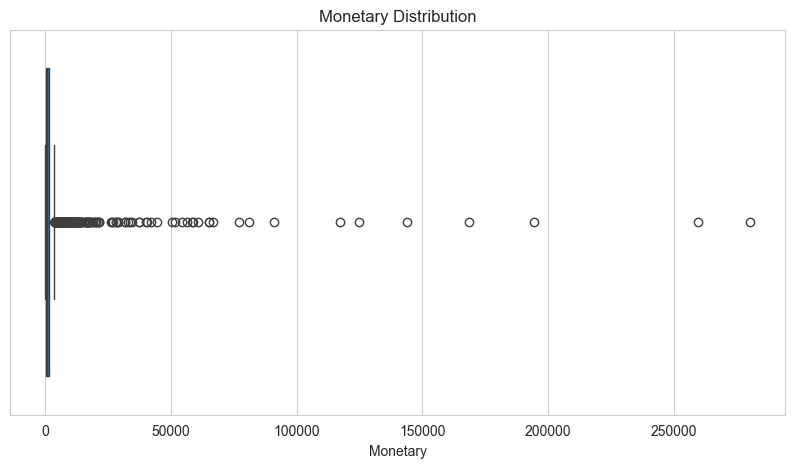

In [102]:
plt.figure(figsize=(10,5))
sns.boxplot(x=rfm["Monetary"])
plt.title("Monetary Distribution")
plt.show()

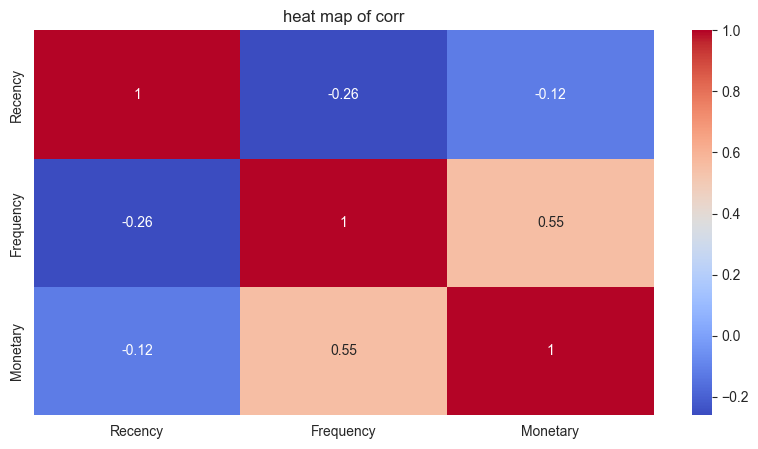

In [103]:
plt.figure(figsize=(10,5))
sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("heat map of corr")
plt.show()